# Week3 - Domain RAG (알고리즘 코칭)

week1~2의 알고리즘 코치 도메인을 그대로 이어, 패턴/문제 풀이 문서를 코퍼스로 한 RAG 파이프라인을 만든다.

- 코퍼스: `data/patterns/*.md` (12) + `data/problems/*.md` (8) = 20개
- 파이프라인: loader → splitter → embedding → FAISS → retriever → 2-step RAG Q&A
- 청킹 전략 2개 비교: recursive vs markdown-header
- 그래프: `retrieve` → `generate` 2-step StateGraph

In [1]:
import os
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv(), override=True)
os.environ["LANGSMITH_TRACING"] = "false"

## 1. 코퍼스 로드

`data/` 아래 마크다운 20개를 로드하고 카테고리(patterns/problems) 메타데이터를 붙인다.

In [2]:
from collections import Counter
from rag.loader import load_documents

docs = load_documents()
print(f"문서 수: {len(docs)}")
print("카테고리:", dict(Counter(d.metadata["category"] for d in docs)))
print("예시 메타:", docs[0].metadata)

문서 수: 20
카테고리: {'patterns': 12, 'problems': 8}
예시 메타: {'source': 'patterns/backtracking.md', 'filename': 'backtracking.md', 'stem': 'backtracking', 'category': 'patterns'}


## 2. 청킹 전략 비교 (recursive vs markdown-header)

- **recursive**: 700자 기준 문자 분할. 길이로 자르므로 한 섹션이 쪼개지거나 코드 블록이 본문과 섞인다.
- **markdown**: `#/##/###` 헤더 기준 분할. 개념/복잡도/코드/실수 같은 의미 단위가 보존된다.

In [3]:
from rag.splitter import split_documents

for strategy in ("recursive", "markdown"):
    chunks = split_documents(docs, strategy)
    print(f"{strategy:>9}: {len(chunks)} chunks")

recursive: 47 chunks
 markdown: 128 chunks


## 3. 인덱싱 (OpenAI 임베딩 + FAISS)

두 전략 각각 FAISS 인덱스를 만들어 `.cache/` 에 저장한다. (`text-embedding-3-small`)

In [4]:
from rag.indexing import build_all

build_all()

[recursive] indexed 47 chunks


[markdown] indexed 128 chunks


{'recursive': 47, 'markdown': 128}

## 4. 청킹 전략별 검색 결과 비교

같은 쿼리를 두 전략으로 검색해 상위 3개 청크를 비교한다.

In [5]:
import pandas as pd
from rag.retriever import retrieve

COMPARE_QUERIES = [
    "답이 단조성을 가질 때 답 자체를 이분 탐색하는 최적화 문제",
    "연속 구간에서 모든 종류를 포함하는 가장 짧은 구간 찾기",
    "작업을 소요 시간이 짧은 것부터 처리해 평균 대기를 줄이는 스케줄링",
    "최소 비용으로 모든 노드를 연결하는 최소 신장 트리",
]

rows = []
for q in COMPARE_QUERIES:
    rec = [d.metadata["chunk_id"] for d in retrieve(q, strategy="recursive", k=3)]
    mdh = [d.metadata["chunk_id"] for d in retrieve(q, strategy="markdown", k=3)]
    rows.append({"query": q, "recursive top-3": ", ".join(rec), "markdown top-3": ", ".join(mdh)})

pd.set_option("display.max_colwidth", None)
pd.DataFrame(rows)

,query,recursive top-3,markdown top-3
0,답이 단조성을 가질 때 답 자체를 이분 탐색하는 최적화 문제,"binary-search-rec-5, binary-search-rec-7, greedy-rec-15","binary-search-md-0, pgs-67258-gem-shopping-md-5, greedy-md-4"
1,연속 구간에서 모든 종류를 포함하는 가장 짧은 구간 찾기,"sliding-window-rec-24, binary-search-rec-5, binary-search-rec-7","pgs-67258-gem-shopping-md-1, heap-md-1, sliding-window-md-5"
2,작업을 소요 시간이 짧은 것부터 처리해 평균 대기를 줄이는 스케줄링,"heap-rec-19, pgs-42627-disk-controller-rec-31, pgs-42627-disk-controller-rec-32","pgs-42627-disk-controller-md-1, pgs-42627-disk-controller-md-2, pgs-42627-disk-controller-md-5"
3,최소 비용으로 모든 노드를 연결하는 최소 신장 트리,"pgs-42861-connecting-islands-rec-34, pgs-42861-connecting-islands-rec-35, pgs-118667-two-queues-rec-29","pgs-42861-connecting-islands-md-1, pgs-42861-connecting-islands-md-4, union-find-md-1"


## 5. 2-step RAG 그래프

`retrieve` (검색 + context 포맷) → `generate` (structured output 답변 + 근거 문서).

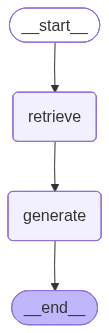

In [6]:
from IPython.display import Image
from graph import graph

Image(graph.get_graph().draw_mermaid_png())

## 6. 최종 테스트 질문 (5개+)

기본 전략은 markdown-header. 답변과 함께 근거 문서(sources), confidence 를 출력한다.

In [7]:
from graph import ask

TEST_QUESTIONS = [
    "입국심사 문제는 왜 이분 탐색으로 푸나요?",
    "보석 쇼핑에서 슬라이딩 윈도우를 좁힐 때 while 을 써야 하는 이유는?",
    "디스크 컨트롤러는 어떤 자료구조로 풀고 핵심 아이디어가 뭔가요?",
    "섬 연결하기에서 union-find 는 어떤 역할을 하나요?",
    "DFS 로 최단 거리를 구하면 안 되는 이유는?",
    "등굣길 문제에서 DP 상태는 어떻게 정의하나요?",
]

for q in TEST_QUESTIONS:
    result = ask(q)
    print("=" * 90)
    print("Q:", q)
    print("A:", result["answer"])
    print("confidence:", result["confidence"])
    print("sources:", result["sources"])

Q: 입국심사 문제는 왜 이분 탐색으로 푸나요?
A: 입국심사 문제는 이분 탐색을 사용하는 이유는 주어진 심사대의 처리 시간이 단조 증가하는 성질을 가지기 때문입니다. 즉, 특정 시간 내에 모든 사람이 심사를 마칠 수 있는지 여부가 시간에 대해 단조롭게 변하기 때문에, 이분 탐색을 통해 효율적으로 최소 시간을 찾을 수 있습니다. 이 문제는 n이 최대 10억 규모로 매우 크기 때문에 선형 접근은 불가능하며, 이분 탐색을 통해 가능한 최소 시간을 빠르게 찾는 것이 적합합니다.
confidence: 0.9
sources: ['problems/pgs-43238-immigration.md', 'patterns/binary-search.md', 'patterns/hash-map.md']


Q: 보석 쇼핑에서 슬라이딩 윈도우를 좁힐 때 while 을 써야 하는 이유는?
A: 보석 쇼핑 문제에서 슬라이딩 윈도우를 좁힐 때 `while`을 사용하는 이유는, `left` 포인터를 한 칸씩 줄이는 `if` 문으로는 최소 윈도우를 놓칠 수 있기 때문입니다. `while` 문을 사용하면 `left` 포인터를 가능한 한 끝까지 이동시켜 윈도우를 최대한 좁힐 수 있습니다. 이렇게 함으로써 모든 보석 종류를 포함하는 최소 길이를 정확히 갱신할 수 있습니다. 이는 슬라이딩 윈도우 기법의 핵심으로, 구간 통계를 유지하면서 효율적으로 문제를 해결하는 데 도움을 줍니다.
confidence: 0.9
sources: ['patterns/hash-map.md', 'problems/pgs-67258-gem-shopping.md', 'patterns/sliding-window.md']


Q: 디스크 컨트롤러는 어떤 자료구조로 풀고 핵심 아이디어가 뭔가요?
A: 디스크 컨트롤러 문제는 주로 **힙(Heap)** 자료구조를 사용하여 해결합니다. 이 문제의 핵심 아이디어는 요청을 도착 시간순으로 정렬한 후, 작업 시간이 짧은 요청을 우선적으로 처리하는 것입니다. 이를 통해 전체 작업의 평균 대기 시간을 최소화할 수 있습니다. 따라서, 요청을 처리할 때는 힙을 활용하여 가장 짧은 작업 시간을 가진 요청을 효율적으로 선택하는 방식으로 접근합니다.
confidence: 0.9
sources: ['patterns/heap.md', 'problems/pgs-42627-disk-controller.md', 'patterns/two-pointers.md']


Q: 섬 연결하기에서 union-find 는 어떤 역할을 하나요?
A: 섬 연결하기 문제에서 union-find는 사이클을 검사하는 역할을 합니다. 이 알고리즘은 간선을 비용 기준으로 오름차순 정렬한 후, 각 간선을 선택할 때 union-find를 사용하여 두 정점이 같은 집합에 속하는지를 확인합니다. 만약 같은 집합이라면 사이클이 발생하므로 그 간선을 건너뛰고, 그렇지 않다면 두 정점을 연결합니다. 이 과정을 반복하여 선택한 간선의 수가 `n-1`이 되면 모든 섬이 연결된 것으로 판단하고 알고리즘을 종료합니다. 따라서 union-find는 크루스칼 알고리즘에서 사이클 방지를 위한 중요한 역할을 수행합니다.
confidence: 0.9
sources: ['patterns/union-find.md', 'problems/pgs-42861-connecting-islands.md', 'patterns/greedy.md']


Q: DFS 로 최단 거리를 구하면 안 되는 이유는?
A: DFS(깊이 우선 탐색)는 최단 거리를 구하는 데 적합하지 않습니다. 그 이유는 DFS가 경로를 탐색할 때, 모든 가능한 경로를 깊이 있게 탐색하기 때문에 최단 경로를 보장하지 않기 때문입니다. 특히, 가중치가 있는 그래프에서 DFS는 최단 경로를 찾는 데 비효율적이며, 가중치가 1인 경우에는 BFS(너비 우선 탐색)가 최단 거리를 구하는 데 적합하다고 알려져 있습니다. 따라서, DFS로 최단 거리를 구하려고 하면 잘못된 결과를 초래할 수 있습니다.
confidence: 0.9
sources: ['patterns/dijkstra.md', 'patterns/bfs-dfs.md', 'problems/pgs-43236-stepping-stones.md', 'problems/pgs-43165-target-number.md']


Q: 등굣길 문제에서 DP 상태는 어떻게 정의하나요?
A: 등굣길 문제에서 DP 상태는 `dp[r][c]`로 정의되며, 이는 (1,1)에서 (r,c)까지의 경로 수를 나타냅니다. 각 칸으로 오는 방법은 위에서 내려오거나 왼쪽에서 오는 두 가지뿐이므로, 상태 전이는 `dp[r][c] = dp[r-1][c] + dp[r][c-1]`로 표현됩니다. 물웅덩이는 0으로 고정하여 경로 수를 계산할 때 이를 고려해야 합니다.
confidence: 0.9
sources: ['problems/pgs-42898-school-path.md', 'patterns/dp.md', 'patterns/greedy.md']
